<a href="https://colab.research.google.com/github/AmulyaVinceChemparathy/dag/blob/main/dag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

node:1:
 1-> 
no of nodes: 3
8->	10->	5->	
no of nodes: 2
9->	4->	
no of nodes: 2
7->	2->	
no of nodes: 1
3->	
last node:
6

printing the matrix form
1	
8	10	5	
9	4	
7	2	
3	
6	


1:	8	-> 10	-> 5	-> 

8: 4 ->

10: 4 ->

5: 9 ->4 ->

9: 7 ->

4: 7 ->7 ->

7: 3 ->

2: 3 ->

3: 6 ->

6: 

Adjacency List:
1: [8, 10, 5]
8: [4]
10: [4]
5: [9, 4]
9: [7]
4: [7, 7]
7: [3]
2: [3]
3: [6]
6: []


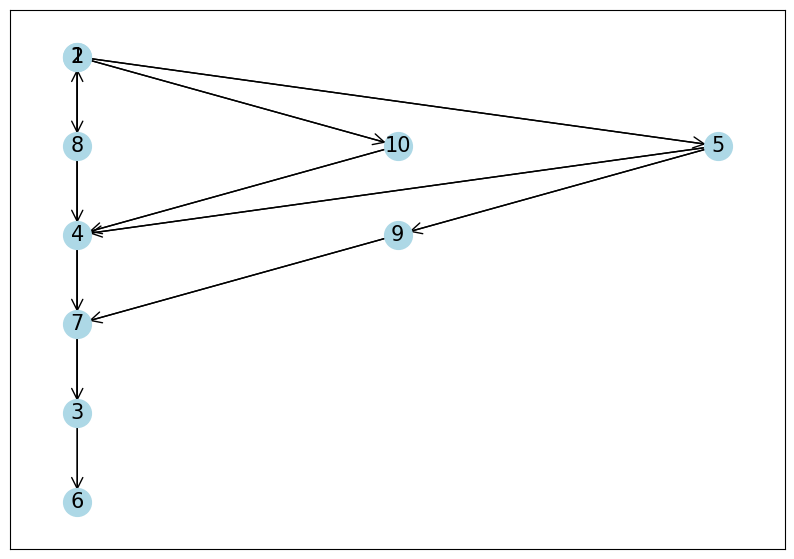

In [3]:
import random
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

G = nx.Graph()
TOTAL_NODES =8
adj_list = {}
MIN_PER_RANK = 3   # Minimum nodes per rank
MAX_PER_RANK =6  # Maximum nodes per rank
MAX_NODES = 10     # Maximum node value

def bfs_levels(adj_list, start_node):
    levels = {}
    queue = deque([(start_node, 0)])
    visited = set([start_node])

    while queue:
        node, level = queue.popleft()
        if level not in levels:
            levels[level] = []
        levels[level].append(node)

        for neighbor in adj_list[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, level + 1))

    return levels

def main():
    random.seed()  # Seed the random number generator
    c = [[0 for _ in range(100)] for _ in range(100)]
    a = [i + 1 for i in range(MAX_NODES)]
    nodes_left = TOTAL_NODES
    row = 1

    print("node:1:")
    l = 0
    k = 0
    n = random.randint(1, MAX_NODES)
    for i in range(MAX_NODES):
        if a[i] != 0 and a[i] == n:
            c[l][k] = n
            print(f" {c[l][k]}-> ")
            a[i] = 0  # Mark node as used
            break

    while nodes_left > 0 and row <= TOTAL_NODES:
        # Generate a random number of nodes for the current row
        nodes_in_row = random.randint(0, min(MAX_PER_RANK, nodes_left))

        # Print the distribution of nodes in the current row
        if nodes_in_row != 0:
            l += 1
            k = 0
            m = nodes_in_row
            print("no of nodes:", nodes_in_row)
            while m > 0:
                n = random.randint(1, MAX_NODES)
                if n!=0:
                    for i in range(MAX_NODES):
                        if a[i] != 0 and a[i] == n:
                            c[l][k] = n
                            print(f"{c[l][k]}->\t", end='')
                            a[i] = 0  # Mark node as used
                            m -= 1
                            k += 1
                            break

        print()
        # Update the number of nodes left and move to the next row
        nodes_left -= nodes_in_row
        row += 1

    print("last node:")
    l += 1
    for i in range(MAX_NODES):
        k = 0
        if a[i] != 0:
            c[l][k] = a[i]
            print(f"{c[l][k]}\n", end='')   # Exit the loop once node is found
    non_zero_rows = 0
    for row in c:
        if any(row):
            non_zero_rows += 1
    #print()
    print("\nprinting the matrix form")
    for i in range(non_zero_rows):
        row_length = sum(1 for element in c[i] if element != 0)
        #print("rowlength: ")
        #print(row_length)
        for j in range(row_length):
            print(f"{c[i][j]}\t", end='')
        print()

    print("\n")
    m2 = 1
    n2 = 0
    print(f"{c[0][0]}:\t", end='')
    adj_list[c[0][0]] = []
    while c[m2][n2]:
        print(f"{c[m2][n2]}\t->", end=' ')
        adj_list[c[0][0]].append(c[m2][n2])
        n2 += 1
    n2=0
    n3=0
    print("\n")
    while(c[m2][0]):
        while(c[m2][n3]):
            row = sum(1 for element in c[m2] if element != 0)
            print(f"{c[m2][n3]}:", end=' ')
            adj_list[c[m2][n3]] = []
            if row == 1:
                next_row = sum(1 for element in c[m2+1] if element != 0)
                for i in range(0,next_row):
                    print(f"{c[m2+1][i]} ", end='->')
                    adj_list[c[m2][n3]].append(c[m2+1][i])
                n3+=1
                print("\n")
            else:
                if 0 <= m2 < len(c):
                    next_row_length = sum(1 for element in c[m2+1] if element != 0)
                    if next_row_length >= 1:
                        rang = random.randint(1, next_row_length)
                        for i in range(0, rang):
                            index = random.randint(0, next_row_length-1)
                            print(f"{c[m2+1][index]} ", end='->')
                            adj_list[c[m2][n3]].append(c[m2+1][index])
                n3+=1
                print("\n")
        n3=0
        m2+=1
    return adj_list

if __name__ == "__main__":
    adj_list = main()
    print("Adjacency List:")
    for node, neighbors in adj_list.items():
        print(f"{node}: {neighbors}")
    for node, neighbors in adj_list.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    levels = bfs_levels(adj_list, next(iter(adj_list)))

    for node, neighbors in adj_list.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    #levels = {value: key for key, value in level1.items()}
    pos = {}
    level_height = 1
    for level, nodes_in_level in levels.items():
        for i, node in enumerate(nodes_in_level):
            pos[node] = (i, -level)

    for node in G.nodes():
        if node not in pos:
            pos[node] = (0, 0)

    plt.figure(figsize=(10, 7))
    nx.draw_networkx(G, pos, with_labels=True, node_size=400, node_color='lightblue', font_size=15, arrows=True)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20)


# Save the graph as an image named "dag.png"
    plt.savefig("dag.png", format="png")